##### Import necessary libraries


In [20]:
import os
import pandas as pd

##### Merge data from each month into one CSV

In [76]:
path = "./Sales_Data"
files = [file for file in os.listdir(path)]

all_months_data = pd.DataFrame()
for file in files:
    current_data = pd.read_csv(f"{path}/{file}")
    all_months_data = pd.concat([all_months_data, current_data])

all_months_data.to_csv("all_data.csv", index=False)

# Read the combined data
df = pd.read_csv("all_data.csv")

df.head()  # Display the first few rows of the DataFrame

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [88]:
print(df.shape)
print(df.columns)

print(df.info())

(161733, 10)
Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address', 'Month', 'Hour', 'Sales', 'City'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161733 entries, 0 to 161732
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          161268 non-null  object        
 1   Product           161268 non-null  object        
 2   Quantity Ordered  160961 non-null  float64       
 3   Price Each        160961 non-null  float64       
 4   Order Date        160961 non-null  datetime64[ns]
 5   Purchase Address  161733 non-null  object        
 6   Month             160961 non-null  float64       
 7   Hour              160961 non-null  float64       
 8   Sales             160961 non-null  float64       
 9   City              161733 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(4)
memor

#### Clean up the data!

In [89]:
# Drop rows of NAN


# Check for missing values
na_df = df[df.isna().any(axis =1)]
na_df.head()

df = df.dropna(how ='all')
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Hour,Sales,City
0,176558,USB-C Charging Cable,2.0,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4.0,8.0,23.90,Dallas (TX)
1,NaN,NaN,NaN,NaN,NaT,,NaN,NaN,NaN,()
2,176559,Bose SoundSport Headphones,1.0,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4.0,22.0,99.99,Boston (MA)
3,176560,Google Phone,1.0,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0,14.0,600.00,Los Angeles (CA)
4,176560,Wired Headphones,1.0,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0,14.0,11.99,Los Angeles (CA)


##### Make columns correct type

In [ ]:
# # Convert columns to correct data types

df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'], errors='coerce')
df['Price Each'] = pd.to_numeric(df['Price Each'], errors='coerce')


df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%y %H:%M', errors='coerce')


#####  Create new columns to help with analysis

In [84]:
df['Month'] = df['Order Date'].dt.month
df['Hour'] = df['Order Date'].dt.hour
df['Sales'] = df['Quantity Ordered'] * df['Price Each']

df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Hour,Sales
0,176558,USB-C Charging Cable,2.0,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4.0,8.0,23.90
1,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1.0,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4.0,22.0,99.99
3,176560,Google Phone,1.0,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0,14.0,600.00
4,176560,Wired Headphones,1.0,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0,14.0,11.99


##### Add City column

In [87]:
def get_city(address):
    if isinstance(address, str) and ',' in address:
        return address.split(',')[1].strip()
    return ''

def get_state(address):
    if isinstance(address, str) and ',' in address:
        parts = address.split(',')
        if len(parts) > 2:
            return parts[2].strip().split(' ')[0]
    return ''

df['Purchase Address'] = df['Purchase Address'].fillna('')
df['City'] = df['Purchase Address'].apply(lambda x: f"{get_city(x)} ({get_state(x)})")

df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Hour,Sales,City
0,176558,USB-C Charging Cable,2.0,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4.0,8.0,23.90,Dallas (TX)
1,NaN,NaN,NaN,NaN,NaT,,NaN,NaN,NaN,()
2,176559,Bose SoundSport Headphones,1.0,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4.0,22.0,99.99,Boston (MA)
3,176560,Google Phone,1.0,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0,14.0,600.00,Los Angeles (CA)
4,176560,Wired Headphones,1.0,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0,14.0,11.99,Los Angeles (CA)


##### Analysis and Answering Business Questions

#### Q1. What was the best month for sales? How much was earned that month?

In [99]:
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

best_month_sales = monthly_sales.max()
best_month = monthly_sales.idxmax()
print(f"The best month for sales was month {best_month} with sales of ${best_month_sales:.2f}")

Month
1.0     1813586.44
2.0     2202022.42
3.0     2807100.38
4.0     3390670.24
5.0     3152606.75
6.0     2577802.26
7.0     2647775.76
8.0     2244467.88
9.0     2097560.13
10.0    3736726.88
11.0    3199603.20
12.0       2816.51
Name: Sales, dtype: float64
The best month for sales was month 10.0 with sales of $3736726.88


#### What city sold the most product?

In [113]:
city_sales = df.groupby('City')['Sales'].sum()
print(city_sales)
best_city_sales = city_sales.max()
print(f"The best city for sales was {city_sales.idxmax()} with sales of ${best_city_sales:.2f}")


products_sold_by_city = df.groupby('City')['Quantity Ordered'].sum()
print(products_sold_by_city)
best_city_products = products_sold_by_city.max()

best_city = products_sold_by_city.idxmax()
print(f"The city with the most products sold is {best_city} with {best_city_products} products sold.")

City
 ()                         0.00
Atlanta (GA)          2434989.31
Austin (TX)           1585304.68
Boston (MA)           3150815.95
Dallas (TX)           2385591.17
Los Angeles (CA)      4769107.88
New York City (NY)    4016679.92
Portland (ME)          397792.20
Portland (OR)         1618835.15
San Francisco (CA)    7153308.09
Seattle (WA)          2360314.50
Name: Sales, dtype: float64
The best city for sales was San Francisco (CA) with sales of $7153308.09
City
 ()                       0.0
Atlanta (GA)          14378.0
Austin (TX)            9633.0
Boston (MA)           19499.0
Dallas (TX)           14430.0
Los Angeles (CA)      28916.0
New York City (NY)    24104.0
Portland (ME)          2398.0
Portland (OR)          9796.0
San Francisco (CA)    43453.0
Seattle (WA)          14351.0
Name: Quantity Ordered, dtype: float64
The city with the most products sold is San Francisco (CA) with 43453.0 products sold.


####  What product sold the most?

In [116]:
products_group = df.groupby('Product')
quantity_ordered = products_group['Quantity Ordered'].sum()
print(quantity_ordered)

most_sold_product = quantity_ordered.idxmax()
print(f'most sold is {most_sold_product} : {quantity_ordered.max()}')

Product
20in Monitor                   3558.0
27in 4K Gaming Monitor         5383.0
27in FHD Monitor               6585.0
34in Ultrawide Monitor         5350.0
AA Batteries (4-pack)         23917.0
AAA Batteries (4-pack)        26777.0
Apple Airpods Headphones      13582.0
Bose SoundSport Headphones    11632.0
Flatscreen TV                  4154.0
Google Phone                   4816.0
LG Dryer                        560.0
LG Washing Machine              586.0
Lightning Charging Cable      20128.0
Macbook Pro Laptop             4084.0
Product                           0.0
ThinkPad Laptop                3589.0
USB-C Charging Cable          20724.0
Vareebadd Phone                1783.0
Wired Headphones              17809.0
iPhone                         5941.0
Name: Quantity Ordered, dtype: float64
most sold is AAA Batteries (4-pack) : 26777.0


##### Visualization

range(1, 13)


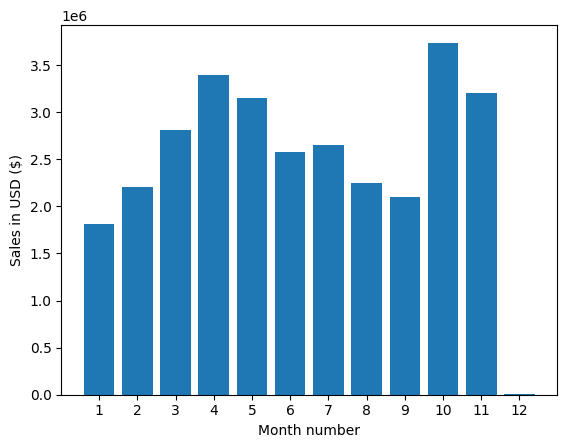

In [ ]:
# What was the best month for sales?
# Visualizing the monthly sales data

import matplotlib.pyplot as plt

months = range(1,13)
print(months)

plt.bar(months,df.groupby(['Month'])['Sales'].sum())
plt.xticks(months)
plt.ylabel('Sales in USD ($)')
plt.xlabel('Month number')
plt.show()

#### Visualizing city wise sales data

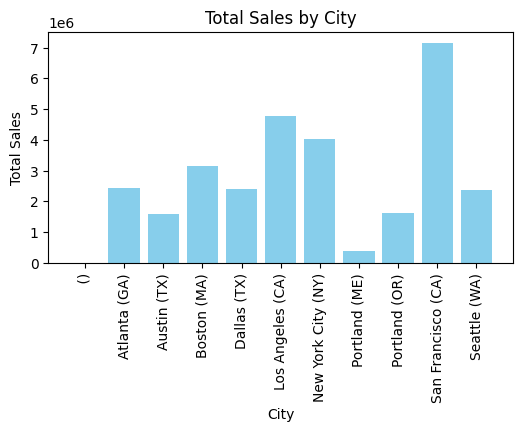

In [128]:
# Visualizing the monthly sales data

import matplotlib.pyplot as plt

# Group data by City and sum the Sales
city_sales = df.groupby('City')['Sales'].sum()

# Extract city names and sales
cities = [city for city, df_city in df.groupby('City')]
sales = city_sales

# Plot
plt.figure(figsize=(6, 3))
plt.bar(cities, sales, color='skyblue')

# Labels
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.title('Total Sales by City')
plt.xticks(rotation='vertical')

plt.show()


#### What product sold the most?

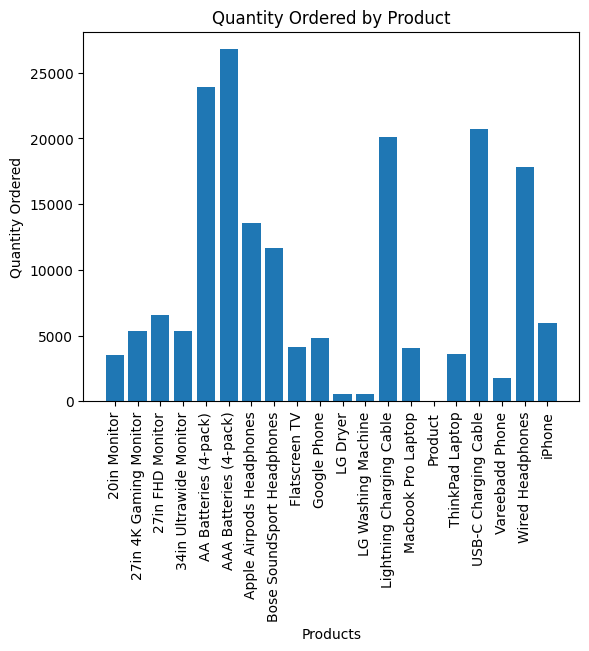

In [130]:
product_group = df.groupby('Product')
quantity_ordered = product_group['Quantity Ordered'].sum()

products = [product for product, df in product_group]

plt.bar(products, quantity_ordered)

plt.xlabel('Products')
plt.ylabel('Quantity Ordered')
plt.title('Quantity Ordered by Product')
plt.xticks(rotation='vertical')

plt.show()